# CS3807 Experiment 5 — Tasks 8, 9, 10
Continuation notebook. Picks up right after Plots 11–12 (Task 7).
Covers:
- **Task 8**: 5-Fold Cross-Validation — Plot 13, configuration table
- **Task 9**: Final Model Evaluation — confusion matrix (Plot 14), precision/recall/F1, params, training time
- **Task 10**: Overall Results table, 23 Discussion Questions, Additional Exercise (2 new configs via 5-fold CV)

⚠️ **Restart points are marked.** Restart the runtime at each marked point, then re-run Step 0 and Step 2 before continuing — otherwise Drive won't be mounted / dataset objects won't exist.

## Step 0 — Run this FIRST in every fresh runtime (mount Drive + checkpoint helpers)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle, os
CKPT_DIR = '/content/drive/MyDrive/CS3807_Exp5'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_result(name, data):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {path}")

def load_result(name):
    with open(os.path.join(CKPT_DIR, f"{name}.pkl"), 'rb') as f:
        return pickle.load(f)

def list_saved():
    return sorted(f for f in os.listdir(CKPT_DIR) if f.endswith('.pkl'))

print("Already saved:", list_saved())

Mounted at /content/drive
Already saved: []


## Step 1 — Installs (once per fresh VM)
After this cell finishes: **Runtime → Restart session**, then re-run Step 0 before continuing.

In [2]:
!pip install -U -q protobuf tensorflow-datasets tensorflow-metadata importlib_resources scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.


## Step 2 — Task 1 Setup (dataset + preprocessing)
Run this every fresh session (same as earlier notebooks — kept identical so variable names line up).

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time, gc

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names
print("Number of classes (breeds):", num_classes)

train_size = int(0.8 * ds_info.splits['train'].num_examples)
ds_train_full_shuffled = ds_train_full.shuffle(1000, seed=SEED)
ds_train = ds_train_full_shuffled.take(train_size)
ds_val = ds_train_full_shuffled.skip(train_size)

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image = tf.image.random_flip_left_right(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, num_classes)
    return image, label

def make_pipeline(ds, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(ds_train, shuffle=True, augment=True)
val_ds   = make_pipeline(ds_val)
test_ds  = make_pipeline(ds_test)

print("Setup complete.")

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.V2OEDJ_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.V2OEDJ_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of classes (breeds): 37
Setup complete.


---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2, before continuing to Task 8.

## Task 8 — 5-Fold Cross-Validation (Plot 13)
The doc says: pick 3–4 promising configurations from your earlier studies (Tasks 2–6) and evaluate each with 5-fold CV **on the training data only** — the test set stays untouched.

**Edit `CONFIGS` below** to reflect what actually won in your earlier plots (best init strategy is already baked into how MobileNetV2 loads its pretrained weights, so the CV configs mainly vary regularization / optimizer / batch size / dropout / BN, per the doc's guidance). The 4 defaults below are reasonable starting picks if you haven't decided yet — swap in your real winners.

In [3]:
# ---- Step A: materialize the full TRAIN split as numpy arrays (needed for KFold indexing) ----
# We use ds_train_full (all ~3680 train images) — NOT ds_test — for cross-validation.

X_list, y_list = [], []
for image, label in tfds.as_numpy(ds_train_full):
    img = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)).numpy().astype('uint8')
    X_list.append(img)
    y_list.append(label)

X_all = np.stack(X_list)          # uint8, raw resized pixels (preprocess_input applied later, per-fold)
y_all = np.array(y_list)
print("X_all:", X_all.shape, "y_all:", y_all.shape)

np.save(os.path.join(CKPT_DIR, 'cv_X_all.npy'), X_all)
np.save(os.path.join(CKPT_DIR, 'cv_y_all.npy'), y_all)
print("Saved CV arrays to Drive.")

X_all: (3680, 224, 224, 3) y_all: (3680,)
Saved CV arrays to Drive.


In [4]:
# ---- Step B: define candidate configurations (EDIT to match your best findings from Tasks 2-6) ----
CONFIGS = {
    'C1': dict(optimizer='adam', lr=1e-3, dropout=0.25, batch_size=32, use_bn=False),   # baseline-ish
    'C2': dict(optimizer='adam', lr=1e-3, dropout=0.5,  batch_size=32, use_bn=True),    # best regularization guess
    'C3': dict(optimizer='adam', lr=1e-4, dropout=0.25, batch_size=16, use_bn=False),   # best LR/batch guess
    'C4': dict(optimizer='rmsprop', lr=1e-3, dropout=0.25, batch_size=64, use_bn=False),# best optimizer guess
}
EPOCHS_CV = 8  # keep modest - 4 configs x 5 folds = 20 training runs

def build_cv_model(cfg):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    if cfg['use_bn']:
        x = tf.keras.layers.BatchNormalization()(x)
    if cfg['dropout'] > 0:
        x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)

    if cfg['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=cfg['lr'])
    elif cfg['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=cfg['lr'], momentum=0.9)
    elif cfg['optimizer'] == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=cfg['lr'])
    else:
        raise ValueError(cfg['optimizer'])

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def make_fold_pipeline(X, y, indices, batch_size, augment):
    Xi, yi = X[indices], y[indices]
    ds = tf.data.Dataset.from_tensor_slices((Xi, yi))
    if augment:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(lambda im, lb: preprocess(im, lb, augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [5]:
# ---- Step C: run 5-fold CV for each config (checkpoints after every fold) ----
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_indices = list(kf.split(X_all))  # same splits reused across all configs -> fair comparison

cv_results = {}   # cv_results[config_name] = {'fold_acc': [...], 'time_sec': total_time}
try:
    cv_results = load_result('cv_results_partial')
    print("Resuming from partial results:", list(cv_results.keys()))
except FileNotFoundError:
    pass

for cfg_name, cfg in CONFIGS.items():
    if cfg_name in cv_results and len(cv_results[cfg_name]['fold_acc']) == 5:
        print(f"Skipping {cfg_name} (already complete).")
        continue

    print(f"\n========== Config {cfg_name}: {cfg} ==========")
    fold_acc = cv_results.get(cfg_name, {}).get('fold_acc', [])
    start_time = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(fold_indices):
        if fold_i < len(fold_acc):
            continue  # already done for this config
        print(f"-- Fold {fold_i + 1}/5 --")
        tf.keras.backend.clear_session(); gc.collect()

        train_fold_ds = make_fold_pipeline(X_all, y_all, train_idx, cfg['batch_size'], augment=True)
        val_fold_ds   = make_fold_pipeline(X_all, y_all, val_idx,   cfg['batch_size'], augment=False)

        model = build_cv_model(cfg)
        history = model.fit(train_fold_ds, validation_data=val_fold_ds,
                             epochs=EPOCHS_CV, verbose=1)
        best_val_acc = max(history.history['val_accuracy']) * 100
        fold_acc.append(best_val_acc)

        cv_results[cfg_name] = {'fold_acc': fold_acc, 'time_sec': time.time() - start_time}
        save_result('cv_results_partial', cv_results)

        del model, history
        tf.keras.backend.clear_session(); gc.collect()

    cv_results[cfg_name]['time_sec'] = time.time() - start_time
    save_result('cv_results_partial', cv_results)
    print(f"{cfg_name} done: {cv_results[cfg_name]['fold_acc']}")

save_result('cv_results_final', cv_results)
print("\nAll configs complete:", cv_results)


========== Config C1: {'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.25, 'batch_size': 32, 'use_bn': False} ==========
-- Fold 1/5 --
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 103ms/step - accuracy: 0.6491 - loss: 1.3494 - val_accuracy: 0.8723 - val_loss: 0.4045
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8849 - loss: 0.3706 - val_accuracy: 0.9158 - val_loss: 0.3074
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9300 - loss: 0.2344 - val_accuracy: 0.9171 - val_loss: 0.2599
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9395 - loss: 0.1889 - val_accuracy: 0.8954 - val_loss: 0.2942
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9596 - loss: 0.1367 - val_accuracy: 0.9185 - val_loss: 0.2506
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9694 - loss: 0.1057 - val_accuracy: 0.8981 - val_loss: 0.2881
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accu

In [6]:
# ---- Step D: configuration table (F1-F5, Mean +- SD) ----
rows = []
for cfg_name, res in cv_results.items():
    accs = res['fold_acc']
    row = {'Configuration': cfg_name}
    for i, a in enumerate(accs):
        row[f'F{i+1}'] = round(a, 2)
    row['Mean'] = round(np.mean(accs), 2)
    row['SD'] = round(np.std(accs), 2)
    row['Mean ± SD'] = f"{np.mean(accs):.2f} ± {np.std(accs):.2f}"
    row['Time (s)'] = round(res['time_sec'], 1)
    rows.append(row)

cv_table = pd.DataFrame(rows).sort_values('Mean', ascending=False).reset_index(drop=True)
print(cv_table.to_string(index=False))
cv_table.to_csv('/content/drive/MyDrive/CS3807_Exp5/plot13_cv_table.csv', index=False)
cv_table

Configuration    F1    F2    F3    F4    F5  Mean   SD    Mean ± SD  Time (s)
           C4 92.12 91.30 92.39 91.58 92.12 91.90 0.40 91.90 ± 0.40     277.2
           C2 92.39 91.17 91.30 91.30 92.80 91.79 0.67 91.79 ± 0.67     250.9
           C1 91.85 90.08 90.76 91.44 91.85 91.20 0.68 91.20 ± 0.68     279.2
           C3 90.22 90.49 90.35 91.17 89.81 90.41 0.44 90.41 ± 0.44     293.8


,Configuration,F1,F2,F3,F4,F5,Mean,SD,Mean ± SD,Time (s)
0,C4,92.12,91.30,92.39,91.58,92.12,91.90,0.40,91.90 ± 0.40,277.2
1,C2,92.39,91.17,91.30,91.30,92.80,91.79,0.67,91.79 ± 0.67,250.9
2,C1,91.85,90.08,90.76,91.44,91.85,91.20,0.68,91.20 ± 0.68,279.2
3,C3,90.22,90.49,90.35,91.17,89.81,90.41,0.44,90.41 ± 0.44,293.8


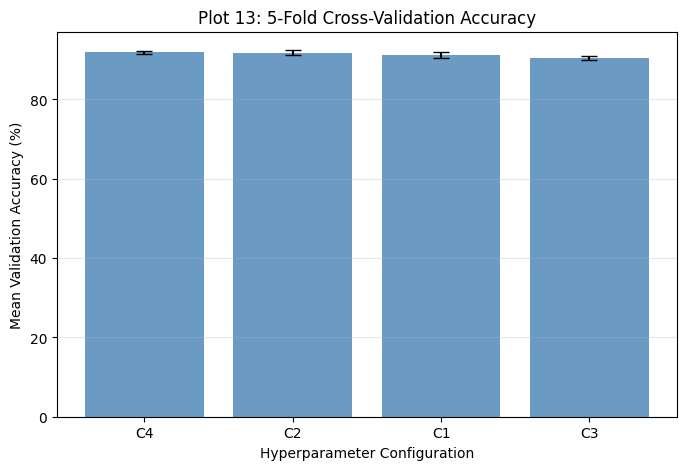

Best configuration by mean CV accuracy: C4
(Also check SD - a slightly lower mean with much lower SD can be the more 'reliable' pick.)
Saved: /content/drive/MyDrive/CS3807_Exp5/best_config_name.pkl


In [7]:
# ---- Plot 13: 5-Fold CV Accuracy with SD error bars ----
plt.figure(figsize=(8, 5))
names = cv_table['Configuration'].tolist()
means = cv_table['Mean'].tolist()
sds = cv_table['SD'].tolist()
plt.bar(names, means, yerr=sds, capsize=6, alpha=0.8, color='steelblue')
plt.xlabel('Hyperparameter Configuration')
plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy')
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot13_cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

best_config_name = cv_table.iloc[0]['Configuration']
print(f"Best configuration by mean CV accuracy: {best_config_name}")
print(f"(Also check SD - a slightly lower mean with much lower SD can be the more 'reliable' pick.)")
save_result('best_config_name', best_config_name)

**Inference to write for Plot 13:** which config has the best mean accuracy, which has the lowest variability (SD), and whether they're the same config — this is exactly what Discussion Question 22/23 below ask about.

---
⚠️ **RESTART POINT** — Runtime → Restart session, then re-run Step 0 and Step 2, before continuing to Task 9.

## Task 9 — Final Model Evaluation (Plot 14)
Retrain the CV-selected configuration on the **complete training data** (all of `ds_train_full`, no held-out val), then evaluate **once** on the untouched test set.

In [8]:
# ---- Step A: recall the best config from Task 8 ----
best_config_name = load_result('best_config_name')
CONFIGS = {
    'C1': dict(optimizer='adam', lr=1e-3, dropout=0.25, batch_size=32, use_bn=False),
    'C2': dict(optimizer='adam', lr=1e-3, dropout=0.5,  batch_size=32, use_bn=True),
    'C3': dict(optimizer='adam', lr=1e-4, dropout=0.25, batch_size=16, use_bn=False),
    'C4': dict(optimizer='rmsprop', lr=1e-3, dropout=0.25, batch_size=64, use_bn=False),
}
best_cfg = CONFIGS[best_config_name]
print("Selected configuration:", best_config_name, best_cfg)

def build_cv_model(cfg):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    if cfg['use_bn']:
        x = tf.keras.layers.BatchNormalization()(x)
    if cfg['dropout'] > 0:
        x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    if cfg['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=cfg['lr'])
    elif cfg['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=cfg['lr'], momentum=0.9)
    elif cfg['optimizer'] == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=cfg['lr'])
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

Selected configuration: C4 {'optimizer': 'rmsprop', 'lr': 0.001, 'dropout': 0.25, 'batch_size': 64, 'use_bn': False}


In [9]:
# ---- Step B: retrain on the FULL training data, then fine-tune (matches Task 7's Case B strategy) ----
EPOCHS_FINAL_FE = 12
EPOCHS_FINAL_FT = 8

full_train_ds = make_pipeline(ds_train_full, shuffle=True, augment=True, batch_size=best_cfg['batch_size'])

tf.keras.backend.clear_session(); gc.collect()
t0 = time.time()

final_model, final_base = build_cv_model(best_cfg)
print("=== Final model: feature-extraction phase on full training data ===")
final_model.fit(full_train_ds, epochs=EPOCHS_FINAL_FE, verbose=1)

# Fine-tune, same recipe as Task 7 (unfreeze last ~30 layers, small LR)
final_base.trainable = True
fine_tune_at = len(final_base.layers) - 30
for layer in final_base.layers[:fine_tune_at]:
    layer.trainable = False
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])
print("=== Final model: fine-tuning phase on full training data ===")
final_model.fit(full_train_ds, epochs=EPOCHS_FINAL_FT, verbose=1)

training_time_sec = time.time() - t0
print(f"Total final training time: {training_time_sec:.1f} sec")

final_model.save('/content/drive/MyDrive/CS3807_Exp5/final_model.keras')
save_result('training_time_sec', training_time_sec)
print("Final model saved.")

=== Final model: feature-extraction phase on full training data ===
Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - accuracy: 0.6891 - loss: 1.2234
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.8785 - loss: 0.4044
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.9228 - loss: 0.2579
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.9383 - loss: 0.1937
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9495 - loss: 0.1488
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.9636 - loss: 0.1147
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.9701 - loss: 0.0973
Epoch 8/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.9788 - loss: 0.0718
Epoch 9/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.9826 - loss: 0.0597
Epoch 10/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9829 - loss: 0.0549
Epoch 11/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accura

In [10]:
# ---- Step C: evaluate ONCE on the untouched test set ----
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

total_params = final_model.count_params()
trainable_params = sum(np.prod(v.shape) for v in final_model.trainable_variables)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,.0f}")
print(f"Training time        : {training_time_sec:.1f} sec")

final_metrics = dict(test_accuracy=test_accuracy, precision=precision, recall=recall, f1=f1,
                      total_params=total_params, trainable_params=int(trainable_params),
                      training_time_sec=training_time_sec)
save_result('final_metrics', final_metrics)

Test Accuracy : 89.37%
Precision (macro): 0.9003
Recall (macro)   : 0.8933
F1-score (macro) : 0.8929
Total parameters    : 2,426,725
Trainable parameters: 1,695,141
Training time        : 284.4 sec
Saved: /content/drive/MyDrive/CS3807_Exp5/final_metrics.pkl


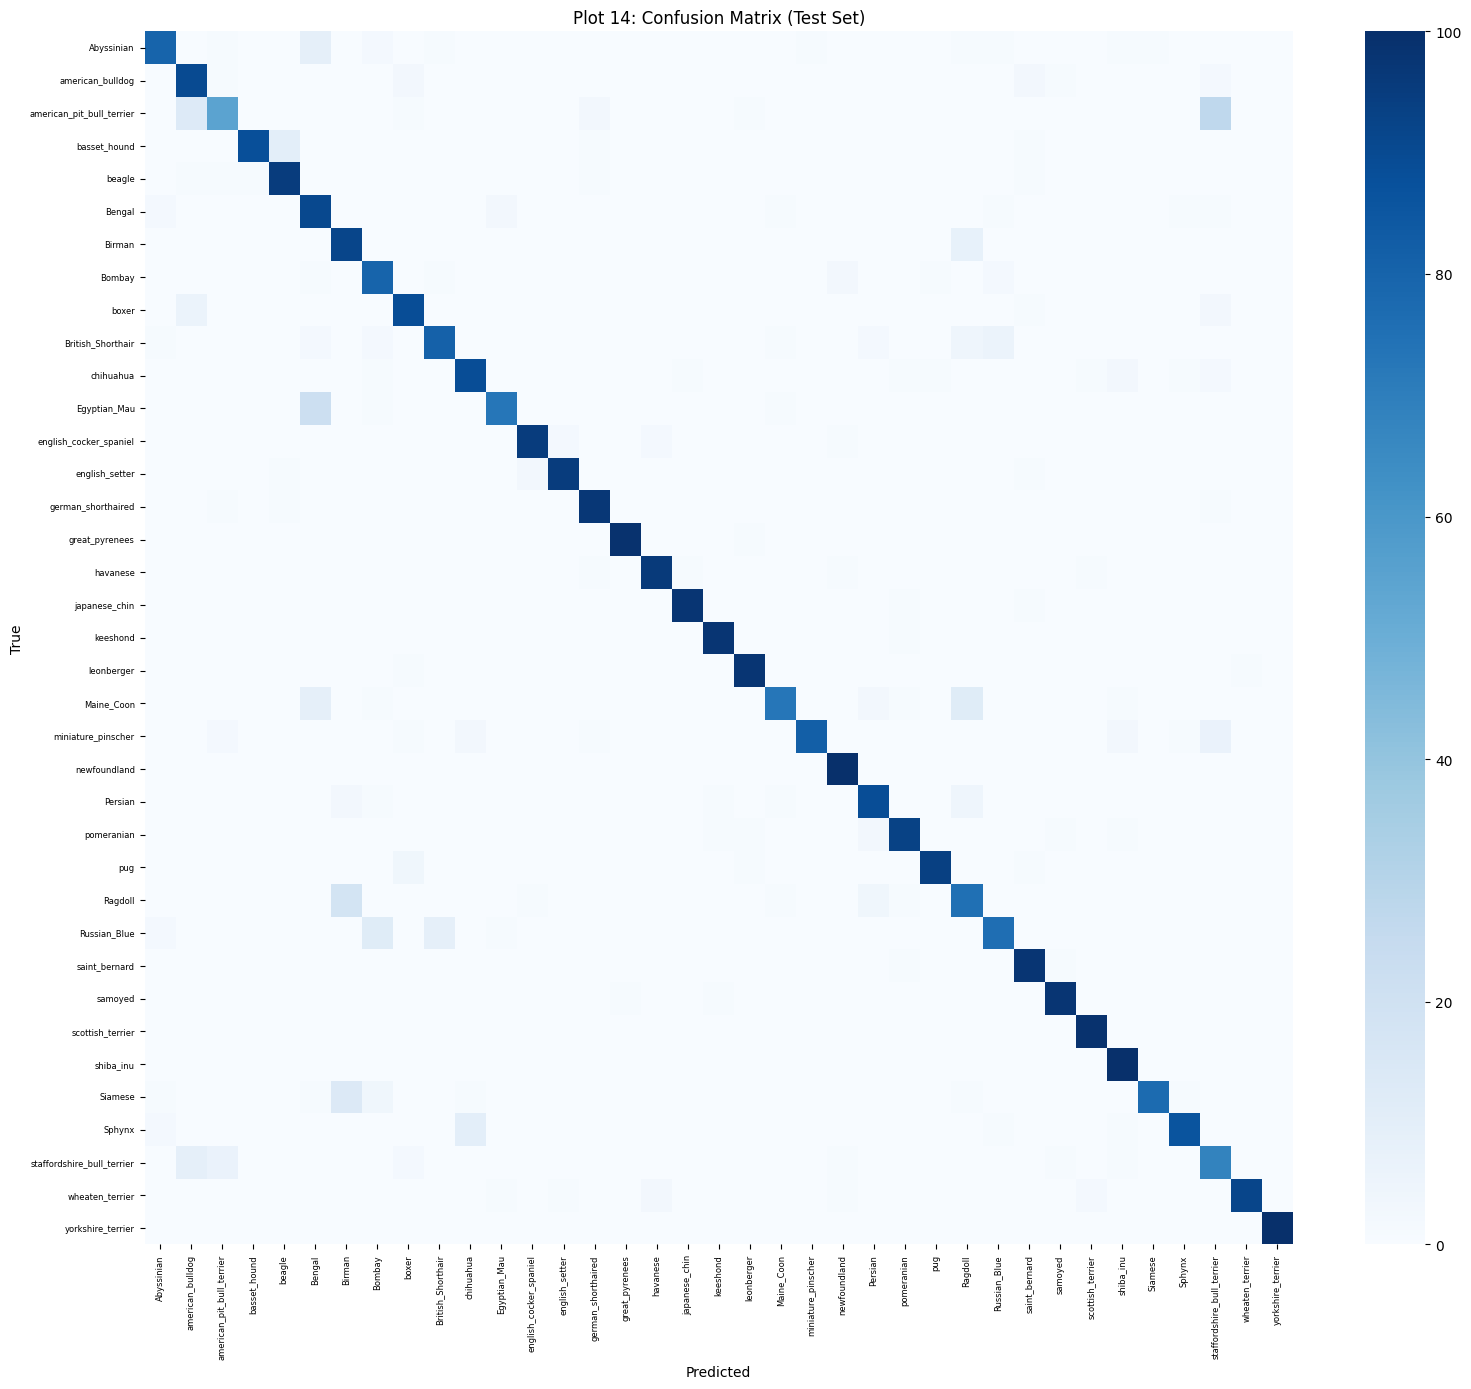

Most frequently confused class pairs (true -> predicted, count):
  american_pit_bull_terrier -> staffordshire_bull_terrier : 27
  Egyptian_Mau              -> Bengal                    : 22
  Ragdoll                   -> Birman                    : 18
  Siamese                   -> Birman                    : 14
  american_pit_bull_terrier -> american_bulldog          : 13
  Maine_Coon                -> Ragdoll                   : 12
  Russian_Blue              -> Bombay                    : 12
  Sphynx                    -> chihuahua                 : 10
  basset_hound              -> beagle                    : 10
  staffordshire_bull_terrier -> american_bulldog          : 9

Best classified classes: [('scottish_terrier', np.float64(100.0)), ('shiba_inu', np.float64(100.0)), ('newfoundland', np.float64(100.0)), ('yorkshire_terrier', np.float64(100.0)), ('great_pyrenees', np.float64(99.0))]
Worst classified classes: [('american_pit_bull_terrier', np.float64(55.0)), ('Maine_Coon', np.f

In [11]:
# ---- Plot 14: Confusion Matrix ----
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Plot 14: Confusion Matrix (Test Set)')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot14_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most-confused class pairs (off-diagonal, top 10)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
top_confused_idx = np.dstack(np.unravel_index(np.argsort(-cm_off, axis=None), cm_off.shape))[0][:10]
print("Most frequently confused class pairs (true -> predicted, count):")
for i, j in top_confused_idx:
    if cm_off[i, j] > 0:
        print(f"  {class_names[i]:25s} -> {class_names[j]:25s} : {cm_off[i, j]}")

# Per-class accuracy, best and worst classified
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes = np.argsort(-per_class_acc)[:5]
worst_classes = np.argsort(per_class_acc)[:5]
print("\nBest classified classes:", [(class_names[i], round(per_class_acc[i]*100,1)) for i in best_classes])
print("Worst classified classes:", [(class_names[i], round(per_class_acc[i]*100,1)) for i in worst_classes])

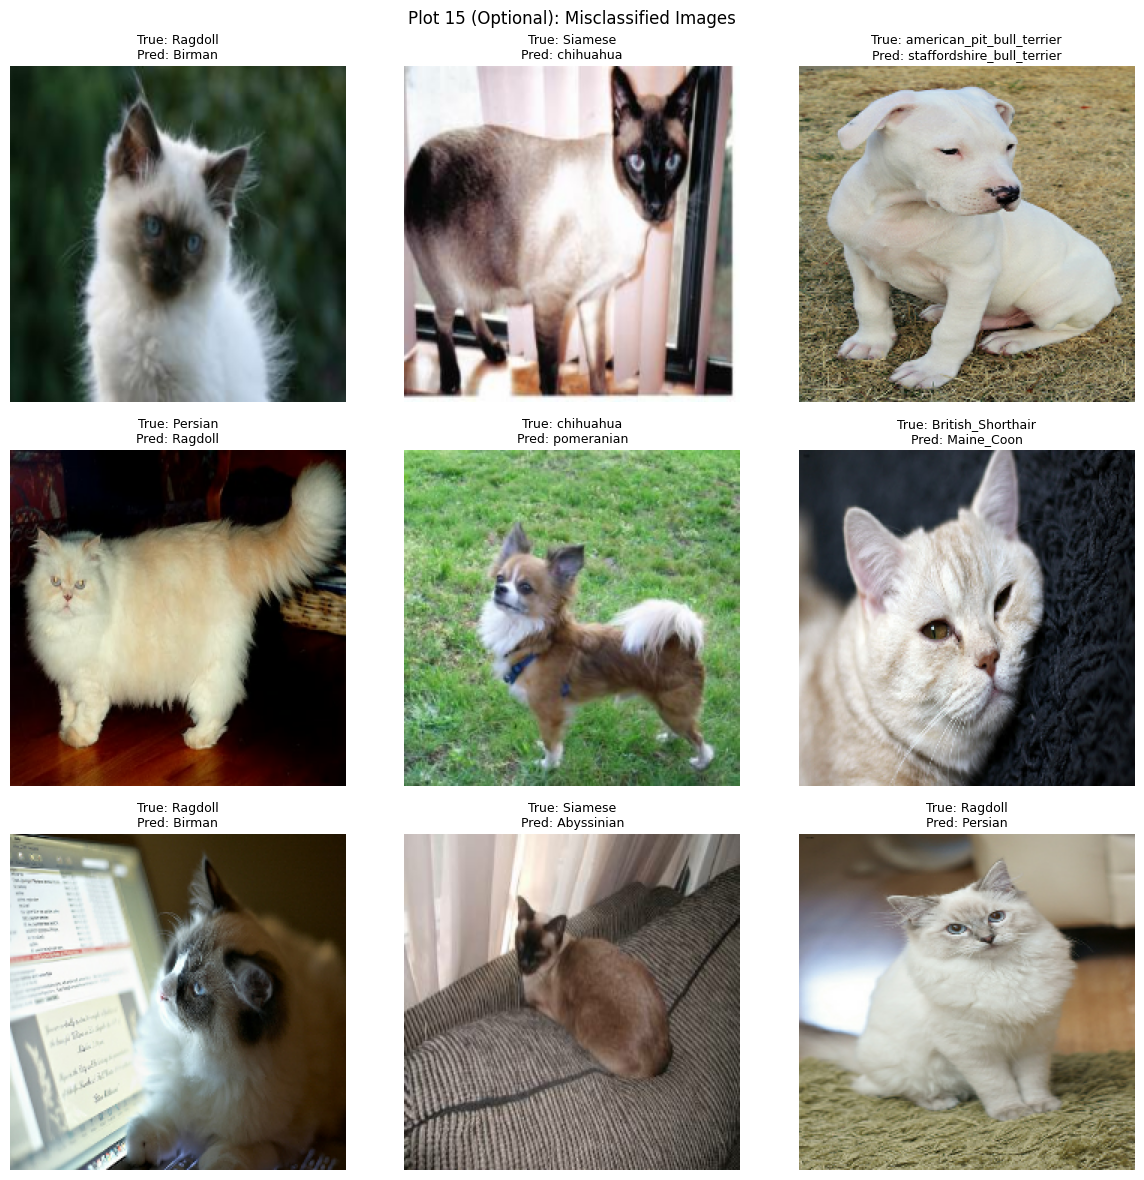

In [12]:
# ---- Optional Plot 15: Misclassified images ----
mis_idx = np.where(y_true != y_pred)[0]
sample_idx = np.random.RandomState(SEED).choice(mis_idx, size=min(9, len(mis_idx)), replace=False)

# Rebuild an unnormalized version of the test set for display purposes
test_ds_display = ds_test.map(lambda im, lb: (tf.image.resize(im, (IMG_SIZE, IMG_SIZE)), lb))
test_images_list, test_labels_list = [], []
for im, lb in tfds.as_numpy(test_ds_display):
    test_images_list.append(im.astype('uint8'))
    test_labels_list.append(lb)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(test_images_list[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
plt.suptitle('Plot 15 (Optional): Misclassified Images')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS3807_Exp5/plot15_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 10 — Overall Results, Discussion Questions, Additional Exercise

### Overall Results table
This pulls together the best numbers from every stage. Cells marked `# FILL IN` need the actual values you read off your earlier plots (Tasks 2–6) — those runs weren't checkpointed with `save_result`, so they can't be auto-loaded here.

In [13]:
cv_results = load_result('cv_results_final')
final_metrics = load_result('final_metrics')
best_config_name = load_result('best_config_name')

overall_rows = [
    # Configuration        , CV Accuracy (%)                 , SD                              , Test Accuracy (%)         , Training Time (s)
    ['Baseline (no reg, default init/opt)', None, None, None, None],   # FILL IN from Task 2/3 plots
    ['Best Initialization',                 None, None, None, None],   # FILL IN from Plot 1/2
    ['Best Regularization',                 None, None, None, None],   # FILL IN from Plot 3/4/5
    ['Best Optimizer',                      None, None, None, None],   # FILL IN from Plot 6/7
    ['Best Hyperparameters',                None, None, None, None],   # FILL IN from Plot 8/9/10
    [f'Best CV Config ({best_config_name})',
        round(np.mean(cv_results[best_config_name]['fold_acc']), 2),
        round(np.std(cv_results[best_config_name]['fold_acc']), 2),
        None, None],
    ['Final Fine-Tuned Model',
        None, None,
        round(final_metrics['test_accuracy'] * 100, 2),
        round(final_metrics['training_time_sec'], 1)],
]

overall_df = pd.DataFrame(overall_rows, columns=['Configuration', 'CV Accuracy (%)', 'SD', 'Test Accuracy (%)', 'Training Time (s)'])
overall_df.to_csv('/content/drive/MyDrive/CS3807_Exp5/overall_results_table.csv', index=False)
overall_df

,Configuration,CV Accuracy (%),SD,Test Accuracy (%),Training Time (s)
0,"Baseline (no reg, default init/opt)",NaN,NaN,NaN,NaN
1,Best Initialization,NaN,NaN,NaN,NaN
2,Best Regularization,NaN,NaN,NaN,NaN
3,Best Optimizer,NaN,NaN,NaN,NaN
4,Best Hyperparameters,NaN,NaN,NaN,NaN
5,Best CV Config (C4),91.9,0.4,NaN,NaN
6,Final Fine-Tuned Model,NaN,NaN,89.37,284.4


### 15. Discussion Questions — answers

1. **Model parameters vs. hyperparameters.** Parameters (weights, biases) are learned automatically from data during training. Hyperparameters (learning rate, batch size, dropout rate, number of layers to unfreeze) are set by the practitioner before/around training and control how learning happens.

2. **Why weight initialization matters.** It sets the starting point of optimization; a poor start can cause very slow convergence, vanishing/exploding gradients, or the network getting stuck, especially in deep networks.

3. **Why zero initialization is problematic.** All neurons in a layer compute identical outputs and receive identical gradients, so they update identically forever ("symmetry"), effectively collapsing the layer's capacity to a single neuron.

4. **Xavier vs. He initialization.** Xavier/Glorot scales weights based on both fan-in and fan-out and assumes a linear/tanh-like activation; He initialization scales only by fan-in with a larger variance, matching ReLU's property of zeroing out roughly half the activations.

5. **Using curves to identify overfitting.** If training accuracy keeps rising (or training loss keeps falling) while validation accuracy plateaus or falls (validation loss rises), the model is memorizing training data rather than generalizing — the growing gap between the two curves is the signature of overfitting.

6. **How Dropout reduces overfitting.** It randomly deactivates a fraction of neurons each training step, preventing co-adaptation between specific neurons and forcing the network to learn redundant, more robust representations — acting like an implicit ensemble.

7. **Purpose of Batch Normalization.** It normalizes layer activations within each mini-batch to stabilize the distribution of inputs to subsequent layers, which speeds up and stabilizes training and provides a mild regularizing effect.

8. **The numerical BN example.** For x = [2,4,6,8], mean = 5 and variance = 5, so std ≈ 2.236, giving normalized values ≈ [-1.342, -0.447, 0.447, 1.342] — zero mean, unit variance for that batch, before the learnable γ, β rescale them.

9. **Roles of γ and β.** After normalization forces zero mean/unit variance, γ and β are learned per-channel to let the network re-scale and re-shift the normalized activations, so BN doesn't strictly restrict what the layer can represent.

10. **SGD vs Momentum vs RMSProp vs Adam.** Plain SGD updates weights using only the current gradient and can oscillate/converge slowly. Momentum adds a running average of past gradients to smooth updates and accelerate through consistent directions. RMSProp adapts the learning rate per parameter using a moving average of squared gradients, helping with noisy or sparse gradients. Adam combines momentum and RMSProp's adaptive scaling, usually giving the fastest, most stable convergence with least tuning.

11. **Learning rate too large.** Updates overshoot minima, causing the loss to oscillate, diverge, or fail to converge at all.

12. **Learning rate too small.** Training converges very slowly and may get stuck in poor local minima or plateaus within a limited number of epochs.

13. **Effect of increasing batch size.** Gradient estimates become less noisy (smoother updates) and hardware utilization improves, but very large batches can generalize slightly worse and need more epochs or a larger learning rate to reach the same accuracy.

14. **Stride and padding.** Stride is the step size the kernel moves across the input (larger stride → smaller, coarser output). Padding adds border pixels (often zeros) so the kernel can process edge pixels and control output spatial size.

15. **Why MobileNetV2 is efficient.** It factorizes standard convolutions into depthwise (per-channel spatial filtering) and pointwise 1×1 (channel mixing) convolutions, drastically cutting multiply-adds, and uses inverted residuals with linear bottlenecks to keep representational power while staying lightweight.

16. **Depthwise separable convolution.** A standard convolution is split into a depthwise convolution (one filter per input channel, no channel mixing) followed by a pointwise 1×1 convolution (mixes channels), which needs far fewer parameters/computation than a full standard convolution.

17. **Transfer learning.** Reusing a model pretrained on a large dataset (e.g., ImageNet) as a starting point for a new, often smaller, related task, so the new model benefits from previously learned general visual features instead of learning from scratch.

18. **Feature extraction vs. fine-tuning.** Feature extraction freezes the pretrained base entirely and only trains a new classifier head on top. Fine-tuning additionally unfreezes some of the pretrained layers (usually the top ones) and updates them slightly, adapting the pretrained features to the new task.

19. **Why fine-tuning uses a smaller learning rate.** The pretrained weights already encode useful, well-tuned features; large updates would overwrite them ("catastrophic forgetting") instead of gently adapting them, so a small learning rate nudges the weights without destroying prior knowledge.

20. **Why K-Fold CV helps hyperparameter selection.** It evaluates each configuration on multiple different train/validation splits, giving a more reliable estimate of generalization performance (and its variability) than a single split, which reduces the risk of picking a configuration that only got lucky on one split.

21. **Why the test set stays untouched during tuning.** If the test set influences any tuning decision, the reported test performance becomes optimistically biased and no longer reflects true generalization to unseen data — it must be reserved for a single, final, unbiased evaluation.

22. **Why report both mean and SD.** The mean summarizes typical performance, but the SD reveals how consistent that performance is across folds; two configs with similar means can have very different reliability, and a lower-mean-but-lower-SD config can be the safer real-world choice.

23. **Is highest validation accuracy always sufficient?** No — it should be weighed against variability (SD across folds), computational cost, training time, and generalization to the untouched test set; a marginally higher but highly variable or far more expensive configuration is often not the best practical choice.

### 16. Additional Exercise
Two new combinations (not used in `CONFIGS` above), evaluated with the same 5-fold CV machinery from Task 8, then compared against the selected configuration.

In [ ]:
# ---- Additional Exercise: 2 new configurations ----
NEW_CONFIGS = {
    'C5': dict(optimizer='sgd', lr=1e-3, dropout=0.5, batch_size=32, use_bn=True),      # heavier reg + momentum SGD
    'C6': dict(optimizer='adam', lr=1e-4, dropout=0.0, batch_size=64, use_bn=True),     # low LR, no dropout, BN only, larger batch
}

for cfg_name, cfg in NEW_CONFIGS.items():
    if cfg_name in cv_results and len(cv_results[cfg_name]['fold_acc']) == 5:
        print(f"Skipping {cfg_name} (already complete).")
        continue
    print(f"\n========== Config {cfg_name}: {cfg} ==========")
    fold_acc = cv_results.get(cfg_name, {}).get('fold_acc', [])
    start_time = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(fold_indices):
        if fold_i < len(fold_acc):
            continue
        print(f"-- Fold {fold_i + 1}/5 --")
        tf.keras.backend.clear_session(); gc.collect()
        train_fold_ds = make_fold_pipeline(X_all, y_all, train_idx, cfg['batch_size'], augment=True)
        val_fold_ds   = make_fold_pipeline(X_all, y_all, val_idx,   cfg['batch_size'], augment=False)
        model, _ = build_cv_model(cfg)
        history = model.fit(train_fold_ds, validation_data=val_fold_ds, epochs=EPOCHS_CV, verbose=1)
        fold_acc.append(max(history.history['val_accuracy']) * 100)
        cv_results[cfg_name] = {'fold_acc': fold_acc, 'time_sec': time.time() - start_time}
        save_result('cv_results_partial', cv_results)
        del model, history
        tf.keras.backend.clear_session(); gc.collect()

    cv_results[cfg_name]['time_sec'] = time.time() - start_time
    save_result('cv_results_partial', cv_results)

save_result('cv_results_final', cv_results)

# ---- Comparison table: original 4 configs + the 2 new ones ----
rows = []
for cfg_name, res in cv_results.items():
    accs = res['fold_acc']
    rows.append({
        'Configuration': cfg_name,
        'Mean (%)': round(np.mean(accs), 2),
        'SD': round(np.std(accs), 2),
        'Time (s)': round(res['time_sec'], 1),
        'New?': 'Yes' if cfg_name in NEW_CONFIGS else 'No',
    })
comparison_table = pd.DataFrame(rows).sort_values('Mean (%)', ascending=False).reset_index(drop=True)
comparison_table.to_csv('/content/drive/MyDrive/CS3807_Exp5/additional_exercise_comparison.csv', index=False)
comparison_table

**Write-up prompt for the exercise (fill in after running):** state whether C5 or C6 beats the Task-8 winner (`best_config_name`) on mean accuracy; then check whether that improvement (if any) survives once you also weigh in the SD (consistency) and the training time (computational cost). A config that wins on mean but has much higher SD or takes much longer to train is often *not* preferable overall — that's the judgment call the doc is asking you to make.